In [1]:
import warnings

import numpy as np
import matplotlib.pyplot as plt

from phase_shift import PhaseConfig, PhaseSolver
from phase_shift.backend import asnumpy
from phase_shift.utils import wrap
from simulator import (GaussianNoise, Scene, carrier_map, circle, gaussian_map, linear_coeffs,
                       masked_map, proportional_coeffs, random_coeffs, random_dips,
                       random_walk_coeffs, rectangle)
from simulator.sequences import random_steps, uniform_steps

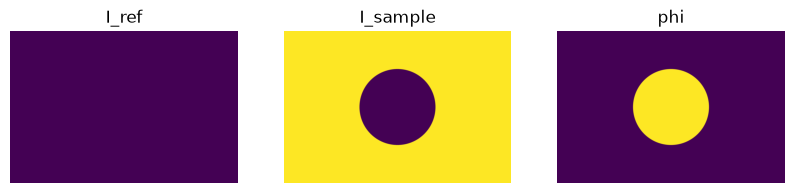

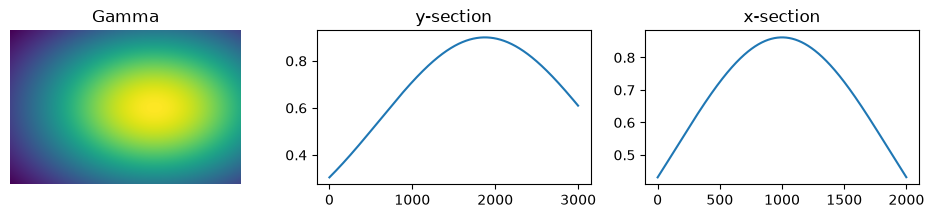

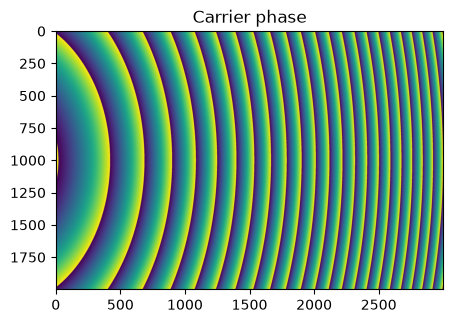

In [2]:
H = 2000 # height in pixels
W = 3000 # width in pixels

# Prepare intenisties of the beams and their phase difference
I_ref = masked_map(rectangle(H, W, H//2, W//2), 1.0, 1.0)
I_sample = masked_map(circle(H, W, H//4), 0.6, 1.0)
phi = masked_map(circle(H, W, H//4), 0.5, 0.3) * np.pi

plt.figure(figsize=(10,5))
plt.subplot(131)
plt.title('I_ref')
plt.imshow(I_ref[0])
plt.axis('off')

plt.subplot(132)
plt.title('I_sample')
plt.imshow(I_sample[0])
plt.axis('off')

plt.subplot(133)
plt.title('phi')
plt.imshow(phi[0])
plt.axis('off')

# Setup coherence envelope (gamma)
gamma = gaussian_map(H,W, (W,H), center=(W//2 + W//8, H//2), peak=0.9)

plt.figure(figsize=(12, 2))
plt.subplot(131)
plt.title('Gamma')
plt.imshow(gamma[0])
plt.axis('off')

plt.subplot(132)
plt.title('y-section')
plt.plot(gamma[0,H//2])

plt.subplot(133)
plt.title('x-section')
plt.plot(gamma[0,:,W//2])

# Setup carrier
carrier=[40.0, 0.0, 8.0, 0.0, 2.0]
carrier_2d = carrier_map(H, W, carrier)

plt.figure(figsize=(5,5))
plt.title('Carrier phase')
plt.imshow(np.angle(np.exp(1j*carrier_2d[0])))

In [3]:
delta_exp_1 = np.array([ 0.        ,  1.37857627,  2.72886032, -1.23574009,  0.85712823,
        2.98917976, -1.18065659,  0.02762735,  1.78226668, -2.23809362,
       -2.42201623,  0.39101139,  1.45159501, -0.39605364,  2.02474844,
       -2.13472211, -0.21334817,  1.98314985,  2.98709987, -1.60213161])

delta_exp_2 = np.array([ 0.        ,  0.69632114,  1.58633512,  2.72654022, -1.36508419,
        0.29456493,  2.19893921, -2.39069963,  0.22629206,  2.42680585,
       -2.00145351, -0.09564679,  2.92696   , -0.88505651,  1.0151397 ,
       -2.85461345,  0.13821859,  1.9427392 , -2.77039615, -0.16929461])


In [11]:
# Levers
N = 20
num = np.arange(start=5, stop=N)        # VP-AIA needs N >= 5
piston_name = "Experiment 1"          # key of `pistons` below
sigma = 2e-2                            # camera noise std; 1e-2 = 0.5%, 1e-1 = 5% of <a>
sigma_alpha = 0.05                      # alpha_n = 1 + sigma_alpha * e_n; corrected
g_rate, g_depth = 0.3, 0.5              # g_n = 1 - Dip(p, d); gain fitted jointly
step_model = "random"                   # "random", "random walk", "linear drift", "proportional"
step_degree = 2                         # degree D of Delta_n; VP-AIA is fitted at degrees 1..D
delta_rms = 0.3                         # total RMS of Delta_n over field and frames, rad
order_weights = (1.0, 0.3, 0.1)         # relative RMS per mode of order 1, 2, 3, ...; first D used
vp_rounds = 3                           # VP-AIA relinearization rounds
seeds = range(1)                        # realizations of alpha, g, Delta and noise per N
show_reference = True                   # also fit AIA on the same data without Delta

pistons = {
    "uniform, 2πn/N": lambda n: uniform_steps(n),
    "Experiment 1": lambda n: delta_exp_1[:n],
    "Experiment 2": lambda n: delta_exp_2[:n],
    "random in [0, 2π)": lambda n: random_steps(n, rng=n),
}
aia_kwargs = {"iters": 30, "tol": 1.0e-4}
configs = {"AIA": PhaseConfig(gain_mode="joint", use_alpha=True, method_kwargs=aia_kwargs)}
for d in range(1, step_degree + 1):
    configs[f"VP-AIA, degree {d}"] = PhaseConfig(
        gain_mode="joint", use_alpha=True, method="vp_aia",
        method_kwargs={**aia_kwargs, "basis_kwargs": {"degree": d}, "rounds": vp_rounds})
phi_true = phi[0] + carrier_2d[0]                          # all methods recover the total static phase

assert len(order_weights) >= step_degree, "order_weights needs one weight per order up to step_degree"
mode_weights = np.concatenate([[order_weights[k - 1]] * (k + 1) for k in range(1, step_degree + 1)])
J = len(mode_weights)                                      # modes of Delta_n: 2, 5, 9, ...
mode_rms = mode_weights / np.sqrt(np.sum(mode_weights ** 2))   # (J,), sum of squares = 1
to_coeff = np.sqrt(H * W)                                  # rad RMS -> VP-AIA coefficient units


def unit_coeffs(model, n, piston, rng):
    """Coefficients (J, n) with zero frame mean whose Delta_n has unit total RMS.

    Mode j gets RMS mode_rms[j] over frames; the modes are orthonormal, so the
    total RMS of Delta_n over field and frames is 1.
    """
    c = {
        "random": lambda: random_coeffs(J, n, rms=1.0, rng=rng),
        "random walk": lambda: random_walk_coeffs(J, n, sigma=1.0, rng=rng),
        "linear drift": lambda: linear_coeffs(n, rng.standard_normal(J)),
        "proportional": lambda: proportional_coeffs(piston, rng.standard_normal(J)),
    }[model]()
    return mode_rms[:, None] * c / np.sqrt(np.mean(c ** 2, axis=1, keepdims=True))


def phase_rmse(phi_rec, phi_true):
    """Wrap-aware RMSE after resolving the global sign and piston ambiguity."""
    errors = []
    for sign in (1, -1):
        d = wrap(sign * phi_rec - phi_true)
        d = wrap(d - np.angle(np.mean(np.exp(1j * d))))
        errors.append(np.sqrt(np.mean(d ** 2)))
    return min(errors)


def fit_rmse(stack, config):
    """Phase RMSE of one fit; NaN when the method rejects the frame count."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            result = PhaseSolver(config).fit(stack.astype(np.float32)).result
        except ValueError:
            return np.nan
    return phase_rmse(asnumpy(result.phi), phi_true)

In [12]:
# AIA and VP-AIA of degrees 1..D for different number of frames, fixed Delta RMS
noise = GaussianNoise(sigma)
curves = {name: [] for name in configs}
if show_reference:
    curves["AIA, Δ = 0 (reference)"] = []
for n in num:
    piston = pistons[piston_name](n)
    assert len(piston) == n, f"{piston_name} has only {len(piston)} steps"
    rows = {name: [] for name in curves}
    for seed in seeds:
        alpha = 1 + sigma_alpha * np.random.default_rng([seed, n, 0]).standard_normal(n)
        assert alpha.min() > 0, "sigma_alpha too large: alpha must stay positive"
        g = random_dips(n, g_rate, g_depth, rng=np.random.default_rng([seed, n, 2]))
        unit = unit_coeffs(step_model, n, piston, np.random.default_rng([seed, n, 3]))  # (J, n)
        noise_seed = [seed, n, 1]                    # same noise for the Delta and reference stacks
        scene = Scene(I_sample, I_ref, gamma, phi, piston, carrier=carrier, alpha=alpha, g=g,
                      coeffs=delta_rms * to_coeff * unit)
        stack = noise(scene.ideal(), rng=np.random.default_rng(noise_seed))
        for name, config in configs.items():
            rows[name].append(fit_rmse(stack, config))
        if show_reference:
            ref = Scene(I_sample, I_ref, gamma, phi, piston, carrier=carrier, alpha=alpha, g=g)
            ref = noise(ref.ideal(), rng=np.random.default_rng(noise_seed))
            rows["AIA, Δ = 0 (reference)"].append(fit_rmse(ref, configs["AIA"]))
    for name in curves:
        curves[name].append(rows[name])
    print(f"N = {n}: done")

N = 5: done
N = 6: done
N = 7: done
N = 8: done
N = 9: done
N = 10: done
N = 11: done
N = 12: done
N = 13: done
N = 14: done
N = 15: done
N = 16: done
N = 17: done
N = 18: done
N = 19: done


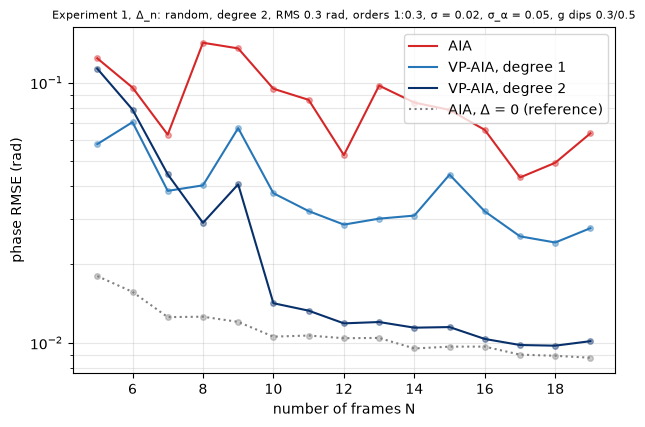

In [13]:
styles = {"AIA": ("C3", "-"), "AIA, Δ = 0 (reference)": ("gray", ":")}
for d in range(1, step_degree + 1):
    styles[f"VP-AIA, degree {d}"] = (plt.cm.Blues(0.45 + 0.55 * d / step_degree), "-")
plt.figure(figsize=(7, 4.5))
for name, values in curves.items():
    values = np.array(values)                                              # (n_N, n_seed)
    c, ls = styles[name]
    for k in range(values.shape[1]):
        plt.semilogy(num, values[:, k], "o", ms=4, color=c, alpha=0.4)
    plt.semilogy(num, values.mean(axis=1), ls, color=c, label=name)
weights = ":".join(f"{w:g}" for w in order_weights[:step_degree])
plt.xlabel("number of frames N")
plt.ylabel("phase RMSE (rad)")
plt.title(f"{piston_name}, Δ_n: {step_model}, degree {step_degree}, RMS {delta_rms:g} rad, "
          f"orders {weights}, σ = {sigma:g}, σ_α = {sigma_alpha:g}, "
          f"g dips {g_rate:g}/{g_depth:g}", fontsize=8)
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

In [14]:
# AIA and full-degree VP-AIA with different numbers of rounds versus Delta RMS, fixed number of frames
from simulator import step_field

n_frames = 12
delta_rms_values = np.geomspace(0.03, 1.0, 10)   # total RMS of Delta_n, rad
rounds_list = [1, 2, 3, 5]                       # exact number of VP-AIA rounds (round_tol = 0)
sweep_sigma = sigma                              # camera noise; 0 shows the convergence floor
seed = 0

sweep_configs = {"AIA": configs["AIA"]}
for r in rounds_list:
    sweep_configs[f"VP-AIA, {r} round{'s' if r > 1 else ''}"] = PhaseConfig(
        gain_mode="joint", use_alpha=True, method="vp_aia",
        method_kwargs={**aia_kwargs, "basis_kwargs": {"degree": step_degree},
                       "rounds": r, "round_tol": 0.0})

piston = pistons[piston_name](n_frames)
assert len(piston) == n_frames, f"{piston_name} has only {len(piston)} steps"
alpha = 1 + sigma_alpha * np.random.default_rng([seed, n_frames, 0]).standard_normal(n_frames)
g = random_dips(n_frames, g_rate, g_depth, rng=np.random.default_rng([seed, n_frames, 2]))
unit = unit_coeffs(step_model, n_frames, piston, np.random.default_rng([seed, n_frames, 3]))
max_per_rms = float(np.abs(step_field(H, W, np.zeros(n_frames), to_coeff * unit)).max())

sweep_noise = GaussianNoise(sweep_sigma)
rmse_vs_delta = {name: [] for name in sweep_configs}
for level in delta_rms_values:
    scene = Scene(I_sample, I_ref, gamma, phi, piston, carrier=carrier, alpha=alpha, g=g,
                  coeffs=level * to_coeff * unit)
    stack = sweep_noise(scene.ideal(), rng=np.random.default_rng([seed, n_frames, 1]))
    for name, config in sweep_configs.items():
        rmse_vs_delta[name].append(fit_rmse(stack, config))
    print(f"Δ RMS = {level:.3g} rad: done")

ref_scene = Scene(I_sample, I_ref, gamma, phi, piston, carrier=carrier, alpha=alpha, g=g)
ref_rmse = fit_rmse(sweep_noise(ref_scene.ideal(), rng=np.random.default_rng([seed, n_frames, 1])),
                    configs["AIA"])

Δ RMS = 0.03 rad: done
Δ RMS = 0.0443 rad: done
Δ RMS = 0.0654 rad: done
Δ RMS = 0.0965 rad: done
Δ RMS = 0.143 rad: done
Δ RMS = 0.21 rad: done
Δ RMS = 0.311 rad: done
Δ RMS = 0.459 rad: done
Δ RMS = 0.677 rad: done
Δ RMS = 1 rad: done


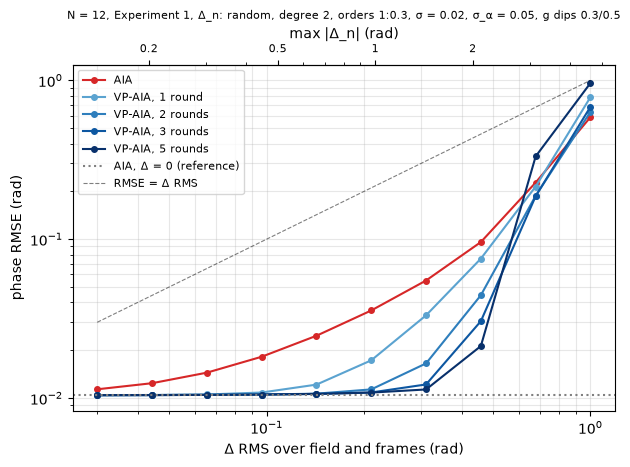

In [16]:
from matplotlib.ticker import FuncFormatter, NullFormatter

sweep_styles = {"AIA": ("C3", "-")}
for i, r in enumerate(rounds_list):
    sweep_styles[f"VP-AIA, {r} round{'s' if r > 1 else ''}"] = (
        plt.cm.Blues(0.4 + 0.6 * (i + 1) / len(rounds_list)), "-")
fig, ax = plt.subplots(figsize=(7, 4.5))
for name, values in rmse_vs_delta.items():
    c, ls = sweep_styles[name]
    ax.loglog(delta_rms_values, values, "o" + ls, ms=4, color=c, label=name)
ax.axhline(ref_rmse, color="gray", ls=":", label="AIA, Δ = 0 (reference)")
ax.loglog(delta_rms_values, delta_rms_values, "k--", lw=0.8, alpha=0.5, label="RMSE = Δ RMS")
top = ax.secondary_xaxis("top", functions=(lambda x: x * max_per_rms, lambda x: x / max_per_rms))
lo, hi = delta_rms_values[0] * max_per_rms, delta_rms_values[-1] * max_per_rms
top.set_xticks([t for t in (0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10) if lo <= t <= hi])
top.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:g}"))
top.xaxis.set_minor_formatter(NullFormatter())
top.tick_params(labelsize=8)
top.set_xlabel("max |Δ_n| (rad)")
weights = ":".join(f"{w:g}" for w in order_weights[:step_degree])
ax.set_xlabel("Δ RMS over field and frames (rad)")
ax.set_ylabel("phase RMSE (rad)")
ax.set_title(f"N = {n_frames}, {piston_name}, Δ_n: {step_model}, degree {step_degree}, "
             f"orders {weights}, σ = {sweep_sigma:g}, σ_α = {sigma_alpha:g}, "
             f"g dips {g_rate:g}/{g_depth:g}", fontsize=8)
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
plt.show()

In [17]:
# Computation time of AIA and full-degree VP-AIA with different numbers of rounds versus N
import time

time_delta_rms = 0.3                    # total RMS of Delta_n, rad
time_rounds = [1, 2, 3, 5]              # exact number of VP-AIA rounds (round_tol = 0)
timing_repeats = 1                      # fits per point; the fastest is kept
seed = 0

time_configs = {"AIA": configs["AIA"]}
for r in time_rounds:
    time_configs[f"VP-AIA, {r} round{'s' if r > 1 else ''}"] = PhaseConfig(
        gain_mode="joint", use_alpha=True, method="vp_aia",
        method_kwargs={**aia_kwargs, "basis_kwargs": {"degree": step_degree},
                       "rounds": r, "round_tol": 0.0})


def fit_seconds(stack, config):
    """Wall time of one fit, until the phase is on the host; NaN if the method rejects N."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        start = time.perf_counter()
        try:
            asnumpy(PhaseSolver(config).fit(stack).result.phi)
        except ValueError:
            return np.nan
        return time.perf_counter() - start


def make_stack(n):
    piston = pistons[piston_name](n)
    assert len(piston) == n, f"{piston_name} has only {len(piston)} steps"
    alpha = 1 + sigma_alpha * np.random.default_rng([seed, n, 0]).standard_normal(n)
    g = random_dips(n, g_rate, g_depth, rng=np.random.default_rng([seed, n, 2]))
    unit = unit_coeffs(step_model, n, piston, np.random.default_rng([seed, n, 3]))
    scene = Scene(I_sample, I_ref, gamma, phi, piston, carrier=carrier, alpha=alpha, g=g,
                  coeffs=time_delta_rms * to_coeff * unit)
    stack = GaussianNoise(sigma)(scene.ideal(), rng=np.random.default_rng([seed, n, 1]))
    return stack.astype(np.float32)


warmup = make_stack(num[0])
for config in time_configs.values():
    fit_seconds(warmup, config)                                            # untimed warm-up
del warmup

fit_times = {name: [] for name in time_configs}
for n in num:
    stack = make_stack(n)
    for name, config in time_configs.items():
        fit_times[name].append(min(fit_seconds(stack, config) for _ in range(timing_repeats)))
    print(f"N = {n}: " + ", ".join(f"{name} {t[-1]:.2f} s" for name, t in fit_times.items()))

N = 5: AIA 0.58 s, VP-AIA, 1 round 1.79 s, VP-AIA, 2 rounds 2.95 s, VP-AIA, 3 rounds 4.04 s, VP-AIA, 5 rounds 6.25 s
N = 6: AIA 0.62 s, VP-AIA, 1 round 1.95 s, VP-AIA, 2 rounds 3.22 s, VP-AIA, 3 rounds 4.43 s, VP-AIA, 5 rounds 6.73 s
N = 7: AIA 0.74 s, VP-AIA, 1 round 2.16 s, VP-AIA, 2 rounds 3.37 s, VP-AIA, 3 rounds 4.68 s, VP-AIA, 5 rounds 7.33 s
N = 8: AIA 0.69 s, VP-AIA, 1 round 2.32 s, VP-AIA, 2 rounds 3.56 s, VP-AIA, 3 rounds 4.83 s, VP-AIA, 5 rounds 7.46 s
N = 9: AIA 0.77 s, VP-AIA, 1 round 2.44 s, VP-AIA, 2 rounds 3.89 s, VP-AIA, 3 rounds 5.28 s, VP-AIA, 5 rounds 8.11 s
N = 10: AIA 0.91 s, VP-AIA, 1 round 2.66 s, VP-AIA, 2 rounds 4.15 s, VP-AIA, 3 rounds 5.67 s, VP-AIA, 5 rounds 8.74 s
N = 11: AIA 0.96 s, VP-AIA, 1 round 2.79 s, VP-AIA, 2 rounds 4.56 s, VP-AIA, 3 rounds 6.04 s, VP-AIA, 5 rounds 9.34 s
N = 12: AIA 1.15 s, VP-AIA, 1 round 3.12 s, VP-AIA, 2 rounds 4.91 s, VP-AIA, 3 rounds 6.64 s, VP-AIA, 5 rounds 10.13 s
N = 13: AIA 0.98 s, VP-AIA, 1 round 3.20 s, VP-AIA, 2 rounds

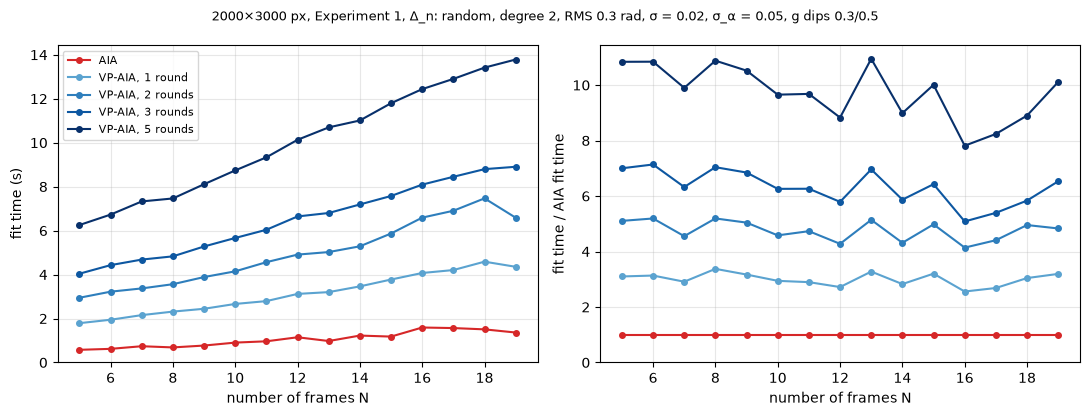

In [18]:
time_styles = {"AIA": "C3"}
for i, r in enumerate(time_rounds):
    time_styles[f"VP-AIA, {r} round{'s' if r > 1 else ''}"] = plt.cm.Blues(0.4 + 0.6 * (i + 1) / len(time_rounds))
aia_times = np.array(fit_times["AIA"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
for name, times in fit_times.items():
    ax1.plot(num, times, "o-", ms=4, color=time_styles[name], label=name)
    ax2.plot(num, np.array(times) / aia_times, "o-", ms=4, color=time_styles[name], label=name)
ax1.set_xlabel("number of frames N")
ax1.set_ylabel("fit time (s)")
ax1.set_ylim(bottom=0)
ax2.set_xlabel("number of frames N")
ax2.set_ylabel("fit time / AIA fit time")
ax2.set_ylim(bottom=0)
for ax in (ax1, ax2):
    ax.grid(True, alpha=0.3)
ax1.legend(fontsize=8)
fig.suptitle(f"{H}×{W} px, {piston_name}, Δ_n: {step_model}, degree {step_degree}, "
             f"RMS {time_delta_rms:g} rad, σ = {sigma:g}, σ_α = {sigma_alpha:g}, "
             f"g dips {g_rate:g}/{g_depth:g}", fontsize=9)
plt.tight_layout()
plt.show()